# 07 — Data-Driven Local Models for Autonomous Racing

## From nonlinear vehicle data to an affine LTV prediction model

Learning MPC for autonomous racing deliberately separates two systems:

1. the **real/simulated vehicle**, represented by a nonlinear dynamic bicycle model;
2. the **prediction model inside the controller**, estimated from data.

The central idea is not to identify one global linear model and hope that it remains valid around
the entire track.

Instead, at each operating point, previous racing data are used to construct

$$
\boxed{
x_{k+1}
\approx
A_k x_k+B_k u_k+c_k
}
$$

where the matrices vary with the local state/input neighborhood.

This gives a **local affine time-varying (LTV) model** suitable for a short-horizon MPC/LMPC
optimization.

The most interesting feature of this prediction model is that it is **hybrid
physics/data-driven**:

- nonlinear vehicle dynamics for $v_x,v_y,r$ are learned locally from data;
- Frenet kinematics for $e_\psi,s,e_y$ are linearized analytically.

This notebook develops that structure from first principles.


## Scope

This notebook builds and validates the data-driven prediction model of a Learning MPC racing
controller, following U. Rosolia and F. Borrelli, “Learning How to Autonomously Race a Car: A
Predictive Control Approach,” *IEEE Transactions on Control Systems Technology*, 28(6), 2020. Its
ingredients are:

- state

$$
x=
[v_x,v_y,r,e_\psi,s,e_y]^\top;
$$

- input ordering in the racing simulator

$$
u=
[\delta,a_x]^\top;
$$

- the dynamic bicycle model of a 1:10-scale RC car (BARC parameters) as the simulated vehicle;
- feasible exploratory laps driven by a noisy PID path-following controller;
- local model identification from stored laps;
- nearest-data selection with a scaled $\ell_1$ distance;
- at most seven local points per stored lap;
- bandwidth $h=5$;
- Epanechnikov (compact-support quadratic) kernel weights;
- structured weighted ridge regression of $v_x,v_y,r$;
- analytical linearization of $e_\psi,s,e_y$;
- a flagged fallback when a lap has no point inside the bandwidth;
- an affine prediction model

$$
x^+=Ax+Bu+c;
$$

- prediction horizon $N=14$ for the multi-step test.

The closed-loop LMPC controller itself is not implemented here; Parts XX–XXIII explain how the
learned model enters it.

For system-identification and validation methodology, the notebook uses standard ideas from
L. Ljung, *System Identification: Theory for the User*; for kernel-weighted local regression, from
T. Hastie, R. Tibshirani and J. Friedman, *The Elements of Statistical Learning*. See also
U. Rosolia, A. Carvalho and F. Borrelli, “Autonomous Racing using Learning Model Predictive
Control,” American Control Conference (ACC), 2017.

## Learning objectives

After completing this notebook, you should be able to:

1. distinguish the nonlinear plant from the learned predictive model;
2. explain why one global linear model is inadequate over a nonlinear racing envelope;
3. define the local regression query vector

$$
z=[v_x,v_y,r,\delta,a_x]^\top;
$$

4. explain why feature scaling is necessary before nearest-neighbor selection;
5. derive the scaled $\ell_1$ distance used for neighbor selection;
6. derive the Epanechnikov (compact-support) kernel weights;
7. formulate weighted affine regression;
8. derive the weighted least-squares normal equations;
9. understand the role of ridge regularization and condition number;
10. explain why the affine offset $c$ is essential;
11. reconstruct the structured regression rows for $v_x,v_y,r$;
12. derive the analytic linearization of the Frenet kinematics;
13. assemble the complete $6\times6$ matrix $A_k$, $6\times2$ matrix $B_k$, and offset $c_k$;
14. validate the learned model on a **different lap**, rather than the fitting samples;
15. compare local and global structured models;
16. construct a horizon-$14$ affine LTV rollout;
17. interpret how $A_k$ and $B_k$ change along the horizon;
18. relate prediction error to distance from the training data;
19. detect extrapolation / missing local support;
20. understand what this model-learning layer contributes to LMPC—and what it does not guarantee.


In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.racing import (
    build_demo_track,
    scale_track_geometry,
    track_global_position,
    pid_control,
    simulate_pid_lap,
    kinematic_affine_linearization,
    LocalRacingModel,
    GlobalRacingModel,
    rollout_affine_predictive_model,
)

np.set_printoptions(
    precision=6,
    suppress=True,
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
})


## Table of Contents

- **[Part I — Plant model versus prediction model](#part-1)** — I.1 The nonlinear “real” system · I.2 Nonlinear lateral tire forces · I.3 Why not put that full nonlinear model directly inside every QP?
- **[Part II — Generate racing data](#part-2)** — II.1 Small RC-car-scale track · II.2 Exploratory seed controller · II.3 Four training laps and one held-out validation lap
- **[Part III — What does the data cloud contain?](#part-3)** — III.1 Transition tuples
- **[Part IV — Local-neighborhood metric](#part-4)** — IV.1 Raw distance would mix incompatible units · IV.2 The Epanechnikov kernel · IV.3 Why select per lap?
- **[Part V — Weighted affine regression](#part-5)** — V.1 Scalar regression problem · V.2 Matrix form · V.3 Normal equations · V.4 Why the affine constant is necessary
- **[Part VI — Structure of the learned model](#part-6)** — VI.1 Learned longitudinal row · VI.2 Learned lateral rows · VI.3 Sparse structure of the learned block
- **[Part VII — Analytical Frenet rows](#part-7)** — VII.1 Why not regress all six state equations? · VII.2 Discrete heading-error equation · VII.3 Jacobian of $e_\psi^+$ · VII.4 Progress equation · VII.5 Lateral-deviation equation · VII.6 Affine remainder
- **[Part VIII — One-step validation on a different lap](#part-8)** — VIII.1 Why training residual is insufficient
- **[Part IX — Why local models help](#part-9)** — IX.1 A nonlinear plant has operating-point-dependent derivatives
- **[Part X — Model support versus prediction error](#part-10)** — X.1 Distance to the database
- **[Part XI — Conditioning and regularization](#part-11)** — XI.1 Why the normal equations can become ill-conditioned · XI.2 Ridge regularization
- **[Part XII — Feature design of the learned rows](#part-12)** — XII.1 Why does $v_x^+$ use acceleration but not steering? · XII.2 Why do $v_y^+$ and $r^+$ use steering but not acceleration?
- **[Part XIII — Building an affine LTV horizon](#part-13)** — XIII.1 From one local model to a sequence · XIII.2 Closed-loop versus prediction model
- **[Part XIV — Horizon-14 prediction experiment](#part-14)** — XIV.1 Use actual future inputs only to test the model
- **[Part XV — Why it is called LTV](#part-15)** — XV.1 The matrices change along the predicted trajectory
- **[Part XVI — Local model support inside an MPC horizon](#part-16)** — XVI.1 One model-fit diagnostic is not enough
- **[Part XVII — Out-of-distribution query](#part-17)** — XVII.1 Deliberately ask for an unfamiliar operating point · XVII.2 Interpretation
- **[Part XVIII — Bias–variance trade-off in bandwidth and neighborhood size](#part-18)** — XVIII.1 Small bandwidth · XVIII.2 Large bandwidth
- **[Part XIX — Why local validation must be trajectory-based](#part-19)** — XIX.1 Random train/test splits can be misleading
- **[Part XX — How this enters LMPC](#part-20)** — XX.1 Two distinct forms of learning · XX.2 Structure of a racing LMPC
- **[Part XXI — The racing LMPC cost: an important detail](#part-21)** — XXI.1 No conventional state-tracking cost for racing · XXI.2 Local safe-set sizing
- **[Part XXII — A subtle geometry issue: convex hulls in Frenet coordinates](#part-22)** — XXII.1 Is a convex local safe set automatically inside the lane?
- **[Part XXIII — Why a learned LTV model can work on a highly nonlinear vehicle](#part-23)** — XXIII.1 The key is not that the plant became linear · XXIII.2 Why this does not automatically imply robustness
- **[Part XXIV — Common pitfalls](#part-24)** — XXIV.1 Pitfall: local linear model means the real system is linear · XXIV.2 Pitfall: nearest neighbors are selected using $(s,e_y)$ · XXIV.3 Pitfall: the regression learns all six state equations · XXIV.4 Pitfall: $c_k$ can be omitted because the model is “linearized” · XXIV.5 Pitfall: low training residual proves predictive accuracy · XXIV.6 Pitfall: large bandwidth is always safer because it uses more data · XXIV.7 Pitfall: ridge regularization is free accuracy · XXIV.8 Pitfall: an extrapolated model is trustworthy because the solver returns coefficients
- **[Part XXV — Check your understanding](#part-25)**
- **[Part XXVI — Exercises](#part-26)**
- **[Part XXVII — References](#part-27)**


<a id="part-1"></a>
# Part I — Plant model versus prediction model

## I.1 The nonlinear “real” system

The vehicle is simulated with the dynamic bicycle model of a 1:10-scale RC car (BARC parameters)
in curvilinear coordinates, as written out in notebook 06 (Part VIII).

The state is

$$
\boxed{
x=
\begin{bmatrix}
v_x&
v_y&
r&
e_\psi&
s&
e_y
\end{bmatrix}^{\!\top}
}
$$

where:

- $v_x$: longitudinal velocity;
- $v_y$: lateral velocity;
- $r$: yaw rate;
- $e_\psi$: heading error relative to the track;
- $s$: curvilinear progress;
- $e_y$: lateral deviation.

The simulator input is

$$
\boxed{
u=
\begin{bmatrix}
\delta\\
a_x
\end{bmatrix},
}
$$

with steering first and longitudinal acceleration second.


## I.2 Nonlinear lateral tire forces

The model uses slip angles

$$
\alpha_f
=
\delta
-
\operatorname{atan2}
\left(
v_y+l_fr,
v_x
\right),
$$

$$
\alpha_r
=
-
\operatorname{atan2}
\left(
v_y-l_rr,
v_x
\right),
$$

and smooth saturating lateral forces

$$
F_{y,f}
=
D_f
\sin
\left(
C_f
\arctan(B_f\alpha_f)
\right),
$$

$$
F_{y,r}
=
D_r
\sin
\left(
C_r
\arctan(B_r\alpha_r)
\right).
$$

This is the simplified Pacejka formula; with the BARC parameters, both axles share $B=1$,
$C=1.25$ and $D=0.8\,mg/2$.

The resulting state transition is nonlinear in both state and steering.


## I.3 Why not put that full nonlinear model directly inside every QP?

One could formulate a nonlinear MPC, but then the online problem would be a nonlinear program.

Learning MPC racing (Rosolia and Borrelli, 2020) instead builds a short-horizon affine
approximation

$$
\boxed{
x_{k+1}
=
A_kx_k+B_ku_k+c_k.
}
$$

This enables the online controller to use a quadratic-program structure while allowing the model
matrices to change with the operating point.

That is the role of local identification:

$$
\boxed{
\text{nonlinear plant}
\quad\longrightarrow\quad
\text{sequence of local affine models}.
}
$$


<a id="part-2"></a>
# Part II — Generate racing data

## II.1 Small RC-car-scale track

The vehicle is a 1:10-scale RC car, so the track must be RC-car sized as well.

We geometrically scale the smooth closed track of notebook 06 by $\alpha=0.08$ and give it a
half-width of $0.4$ m.

Scaling geometry by $\alpha$ gives

$$
s_{\mathrm{new}}=\alpha s,
$$

but curvature scales inversely:

$$
\boxed{
K_{\mathrm{new}}
=
\frac{K}{\alpha}.
}
$$

This preserves the geometry up to scale.


In [2]:
base_track = build_demo_track(
    n=400,
    half_width=3.0,
)

track = scale_track_geometry(
    base_track,
    factor=0.08,
    half_width=0.4,
)

print(
    f"track length = {track.length:.3f} m"
)

print(
    "curvature range =",
    (
        float(track.curvature.min()),
        float(track.curvature.max()),
    ),
)

print(
    "minimum Frenet margin 1-|K|W =",
    float(
        np.min(
            1.0
            - np.abs(track.curvature)
            * track.half_width
        )
    ),
)


track length = 20.187 m
curvature range = (-0.15691865602519606, 1.6264394896759422)
minimum Frenet margin 1-|K|W = 0.34942420412962305


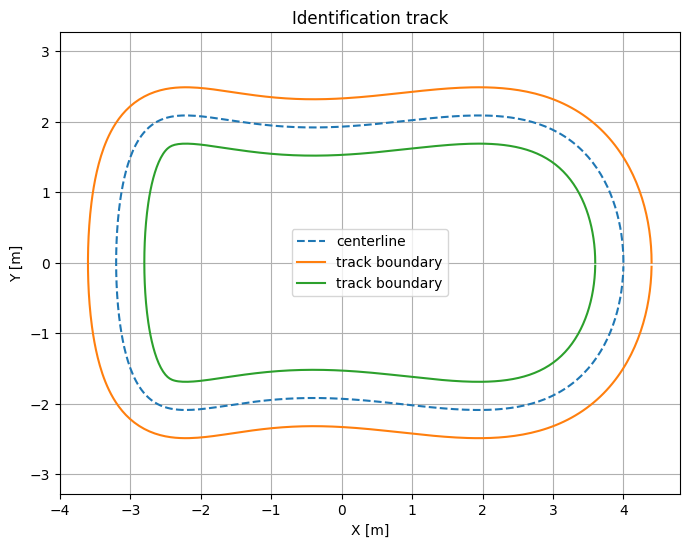

In [3]:
inner = track.to_global(
    -track.half_width
)

outer = track.to_global(
    track.half_width
)

plt.figure(figsize=(8, 6))

plt.plot(
    track.xy[:, 0],
    track.xy[:, 1],
    "--",
    label="centerline",
)

plt.plot(
    inner[:, 0],
    inner[:, 1],
    label="track boundary",
)

plt.plot(
    outer[:, 0],
    outer[:, 1],
    label="track boundary",
)

plt.axis("equal")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Identification track")
plt.legend()
plt.show()


## II.2 Exploratory seed controller

Learning starts from suboptimal but feasible laps driven by a simple centerline controller, the
noisy PID path-following controller `pid_control`.

Its structure is

$$
\boxed{
\delta
=
-0.6e_y
-
0.9e_\psi
+
\text{steering dither},
}
$$

$$
\boxed{
a_x
=
1.5(v_t-v_x)
+
\text{acceleration dither}.
}
$$

Here $v_t$ is the target speed: $0.8$ m/s for the training laps and $0.85$ m/s for the validation
lap. The dither is clipped Gaussian noise, drawn independently at every step.

The dither is important for identification: if the vehicle repeats exactly the same constant-input
behavior, many local parameters become poorly excited.

One safety choice is made explicitly:

> the exploratory action is clipped to the input bounds of the Learning MPC racing controller,
> $|\delta|\le0.5$ and $|a_x|\le10$.

The dither is added before clipping, so every recorded input satisfies the bounds that the
controller will later impose.


## II.3 Four training laps and one held-out validation lap

A Learning MPC racing controller starts from data recorded with such a simple feasible controller.

For identification diagnostics, we generate **four exploratory training laps with the same
controller and different deterministic random seeds**.

This gives the regression a richer data cloud and makes train-versus-validation analysis
meaningful.

A fifth lap is kept completely out of the fit.


In [4]:
training_laps = []

for seed in range(4):
    X, U = simulate_pid_lap(
        track,
        seed=seed,
        target_speed=0.8,
        inner_dt=0.001,
        enforce_lmpc_bounds=True,
    )

    training_laps.append(
        (X, U)
    )

    print(
        f"training lap {seed}: "
        f"{len(U):3d} samples, "
        f"time={0.1*len(U):5.2f} s, "
        f"max |ey|={np.max(np.abs(X[:,5])):.3f} m"
    )

X_val, U_val = simulate_pid_lap(
    track,
    seed=20,
    target_speed=0.85,
    inner_dt=0.001,
    enforce_lmpc_bounds=True,
)

print(
    "\nvalidation lap:",
    len(U_val),
    "samples, time=",
    0.1 * len(U_val),
    "s",
)


training lap 0: 304 samples, time=30.40 s, max |ey|=0.355 m


training lap 1: 304 samples, time=30.40 s, max |ey|=0.307 m


training lap 2: 304 samples, time=30.40 s, max |ey|=0.290 m


training lap 3: 304 samples, time=30.40 s, max |ey|=0.242 m



validation lap: 295 samples, time= 29.5 s


### Why is the validation lap different?

It uses a different exploration realization and a slightly different target speed.

The validation samples therefore remain close to the racing operating domain but are not identical
copies of the training transitions.

This is more informative than reporting the residual on the points used to compute the regression.


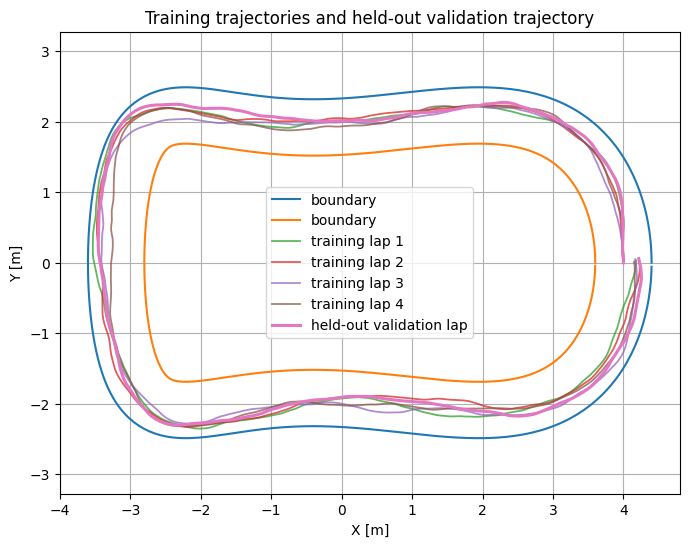

In [5]:
plt.figure(figsize=(8, 6))

plt.plot(
    inner[:, 0],
    inner[:, 1],
    label="boundary",
)

plt.plot(
    outer[:, 0],
    outer[:, 1],
    label="boundary",
)

for j, (X, U) in enumerate(training_laps):
    xy = track_global_position(
        track,
        X[:, 4],
        X[:, 5],
    )

    plt.plot(
        xy[:, 0],
        xy[:, 1],
        linewidth=1.3,
        alpha=0.75,
        label=f"training lap {j+1}",
    )

xy_val = track_global_position(
    track,
    X_val[:, 4],
    X_val[:, 5],
)

plt.plot(
    xy_val[:, 0],
    xy_val[:, 1],
    linewidth=2.2,
    label="held-out validation lap",
)

plt.axis("equal")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Training trajectories and held-out validation trajectory")
plt.legend()
plt.show()


### How to read this figure

Every curve is a complete lap of the nonlinear simulator.

The four training curves provide the identification database.

The validation curve is **not** included in that database.

The curves are close because they solve the same centerline-following task, but the random
steering and acceleration dither (a different seed for every lap) makes the state/input samples
different.


<a id="part-3"></a>
# Part III — What does the data cloud contain?

## III.1 Transition tuples

Every stored lap provides samples

$$
\boxed{
(x_i,u_i,x_i^+)
}
$$

with

$$
x_i^+
=
x_{i+1}.
$$

For model learning, only selected parts of these vectors are used.

The local operating-point query is

$$
\boxed{
z
=
\begin{bmatrix}
v_x&
v_y&
r&
\delta&
a_x
\end{bmatrix}^{\!\top}.
}
$$

Notice what is **not** in the neighbor metric:

$$
e_\psi,\quad s,\quad e_y.
$$

The dynamic regression therefore searches for similar vehicle dynamic states and inputs independent
of where they occurred on the track.

Track geometry is then reintroduced analytically in the Frenet kinematic rows.


In [6]:
X_train = np.vstack([
    X[:-1]
    for X, U in training_laps
])

U_train = np.vstack([
    U
    for X, U in training_laps
])

print("total training transitions:", len(X_train))

labels = [
    "vx",
    "vy",
    "r",
    "delta",
    "ax",
]

mins = np.r_[
    X_train[:, :3].min(axis=0),
    U_train.min(axis=0),
]

maxs = np.r_[
    X_train[:, :3].max(axis=0),
    U_train.max(axis=0),
]

for label, lo, hi in zip(
    labels,
    mins,
    maxs,
):
    print(
        f"{label:6s}: "
        f"[{lo: .5f}, {hi: .5f}]"
    )


total training transitions: 1216
vx    : [ 0.47474,  0.79958]
vy    : [-0.10650,  0.10877]
r     : [-1.33800,  1.39914]
delta : [-0.50000,  0.50000]
ax    : [-0.17487,  0.57892]


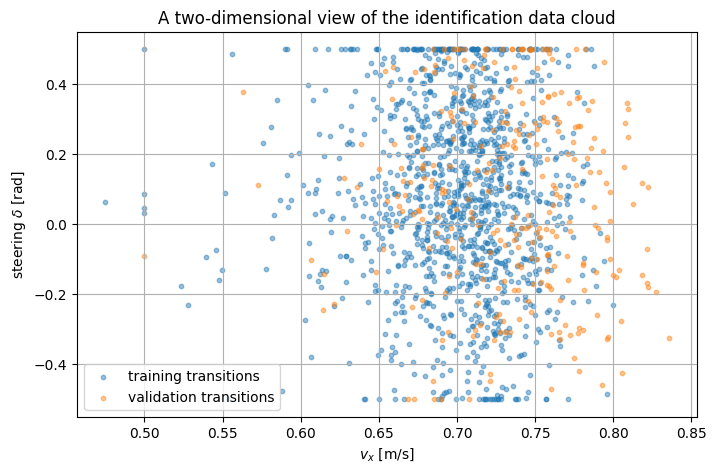

In [7]:
fig = plt.figure(figsize=(8, 5))
ax = fig.gca()

ax.scatter(
    X_train[:, 0],
    U_train[:, 0],
    s=10,
    alpha=0.45,
    label="training transitions",
)

ax.scatter(
    X_val[:-1, 0],
    U_val[:, 0],
    s=10,
    alpha=0.45,
    label="validation transitions",
)

ax.set_xlabel(r"$v_x$ [m/s]")
ax.set_ylabel(r"steering $\delta$ [rad]")
ax.set_title("A two-dimensional view of the identification data cloud")
ax.legend()
plt.show()


### How to read the data-cloud figure

Each point is one transition.

The axes show only two of the five variables used for neighbor selection.

Overlap in this projection does **not** imply two transitions are identical in

$$
[v_x,v_y,r,\delta,a_x].
$$

The purpose of the figure is only to show that the held-out lap lives in approximately the same
operating envelope. Because of its higher target speed, a few validation transitions reach slightly
higher $v_x$ than any training transition.

The dense rows at $\delta=\pm0.5$ rad are transitions where the dithered steering command was
clipped to the input bound.


<a id="part-4"></a>
# Part IV — Local-neighborhood metric

## IV.1 Raw distance would mix incompatible units

The query vector contains:

- velocity;
- yaw rate;
- steering angle;
- acceleration.

A direct Euclidean or $\ell_1$ norm would depend strongly on their numerical units and scales.

The implementation uses

$$
\boxed{
D
=
\operatorname{diag}
(0.1,1,1,1,1)
}
$$

and computes a scaled $\ell_1$ distance

$$
\boxed{
d_i
=
\left\|
D(z_i-z_q)
\right\|_1.
}
$$

The smaller coefficient on $v_x$ reduces the dominance of longitudinal-speed differences.


## IV.2 The Epanechnikov kernel

The implementation uses bandwidth

$$
\boxed{
h=5
}
$$

and the Epanechnikov kernel weight

$$
\boxed{
w_i
=
\frac34
\left[
1-
\left(
\frac{d_i}{h}
\right)^2
\right]
}
$$

for points satisfying

$$
d_i<h.
$$

Thus:

- the query-nearest points receive the largest weight;
- weight decreases quadratically with distance;
- points outside the bandwidth are excluded.

At most

$$
\boxed{
7
}
$$

points are retained from each stored lap: the nearest ones inside the bandwidth.

If a lap has no point inside the bandwidth, its seven nearest transitions are used instead, the
bandwidth is widened for that lap just enough to cover them, and the lap is flagged as a support
fallback (Part XVII).

## IV.3 Why select per lap?

If all samples were pooled and the nearest points selected globally, one dense trajectory could
dominate the regression.

Selecting a small local subset **from each lap** ensures that several successful executions
contribute.

Here four training laps are stored, so at most

$$
4\times7=28
$$

samples enter one local regression.


In [8]:
local_model = LocalRacingModel(
    track,
    dt=0.1,
    max_points_per_lap=7,
    bandwidth=5.0,
    ridge=1e-8,
)

global_model = GlobalRacingModel(
    track,
    dt=0.1,
    ridge=1e-8,
)

for X, U in training_laps:
    local_model.add_trajectory(
        X,
        U,
    )

    global_model.add_trajectory(
        X,
        U,
    )

query_index = 120

xq = X_val[query_index]
uq = U_val[query_index]

Aq, Bq, cq, diag_q = local_model.fit(
    xq,
    uq,
)

print("query state:")
print(xq)

print("\nquery input:")
print(uq)

print(
    "\nlocal curvature:",
    diag_q.curvature,
)


query state:
[ 0.749705  0.093364  1.369887 -0.231015  8.111228 -0.312796]

query input:
[0.290176 0.227437]

local curvature: 1.4302861700213083


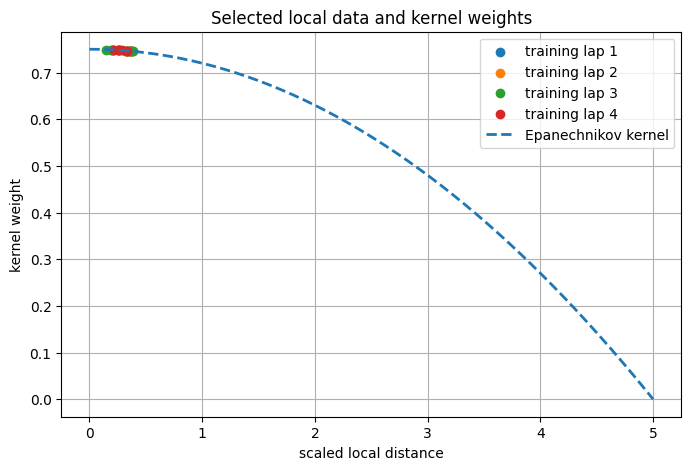

In [9]:
all_distances = np.concatenate(
    diag_q.selected_distances
)

all_weights = np.concatenate(
    diag_q.selected_weights
)

lap_id = np.concatenate([
    np.full(
        len(d),
        j,
    )
    for j, d
    in enumerate(
        diag_q.selected_distances
    )
])

plt.figure()

for j in range(4):
    mask = lap_id == j

    plt.scatter(
        all_distances[mask],
        all_weights[mask],
        label=f"training lap {j+1}",
    )

distance_curve = np.linspace(
    0.0,
    5.0,
    200,
)

kernel_curve = (
    0.75
    * (
        1.0
        - (distance_curve / 5.0) ** 2
    )
)

plt.plot(
    distance_curve,
    kernel_curve,
    "--",
    linewidth=2,
    label="Epanechnikov kernel",
)

plt.xlabel("scaled local distance")
plt.ylabel("kernel weight")
plt.title("Selected local data and kernel weights")
plt.legend()
plt.show()


### How to read the kernel figure

A point near the left side is dynamically/input-wise similar to the current query.

Its regression weight is therefore high.

Points near the bandwidth edge

$$
d=h=5
$$

would have almost zero influence.

In this figure, however, all selected points (seven from each of the four stored laps) lie very
close to the query compared with the bandwidth, so their weights are all close to the maximum
$3/4$. On this RC-car-scale data, the ranges of the five features printed in Part III, weighted by
$(0.1,1,1,1,1)$, add up to less than $h$: for any query inside the data envelope, every stored transition lies inside the
bandwidth. The seven-points-per-lap rule therefore does the actual selection, and the kernel
weights are nearly uniform. A smaller bandwidth would be needed for the shape of the kernel to
matter (Exercise 3).

<a id="part-5"></a>
# Part V — Weighted affine regression

## V.1 Scalar regression problem

For one state component, write

$$
y_i
=
x_{i+1,j}.
$$

Let

$$
\phi_i
=
\begin{bmatrix}
\text{selected regressors}\\
1
\end{bmatrix}.
$$

The final constant $1$ creates an affine offset.

The local model solves

$$
\boxed{
\theta^\star
=
\arg\min_\theta
\sum_i
w_i
\left(
y_i-\phi_i^\top\theta
\right)^2
+
\lambda
\|\theta\|_2^2.
}
$$


## V.2 Matrix form

Stack the regressors:

$$
\Phi
=
\begin{bmatrix}
\phi_1^\top\\
\vdots\\
\phi_m^\top
\end{bmatrix},
$$

outputs

$$
y=
[y_1,\ldots,y_m]^\top,
$$

and weights

$$
W=
\operatorname{diag}
(w_1,\ldots,w_m).
$$

Then

$$
\boxed{
\theta^\star
=
\arg\min_\theta
(y-\Phi\theta)^\top
W
(y-\Phi\theta)
+
\lambda\theta^\top\theta.
}
$$


## V.3 Normal equations

Set the gradient to zero:

$$
-2\Phi^\top W
(y-\Phi\theta)
+
2\lambda\theta
=
0.
$$

Therefore

$$
\boxed{
\left(
\Phi^\top W\Phi
+
\lambda I
\right)
\theta^\star
=
\Phi^\top Wy.
}
$$

If the matrix is nonsingular,

$$
\boxed{
\theta^\star
=
\left(
\Phi^\top W\Phi
+
\lambda I
\right)^{-1}
\Phi^\top Wy.
}
$$

Setting

$$
\lambda=0
$$

gives ordinary weighted least squares. The implementation here uses a tiny ridge value,
$\lambda=10^{-8}$, only as a safeguard against an exactly singular normal matrix.


## V.4 Why the affine constant is necessary

Suppose the nonlinear transition is

$$
x^+=f(x,u).
$$

Linearization around

$$
(x_q,u_q)
$$

gives

$$
x^+
\approx
f(x_q,u_q)
+
A_q(x-x_q)
+
B_q(u-u_q).
$$

Rearrange:

$$
\boxed{
x^+
\approx
A_qx+B_qu+c_q,
}
$$

where

$$
c_q
=
f(x_q,u_q)
-
A_qx_q
-
B_qu_q.
$$

Unless the operating point is the origin and the map passes through the origin, forcing

$$
c_q=0
$$

creates a systematic bias.


<a id="part-6"></a>
# Part VI — Structure of the learned model

## VI.1 Learned longitudinal row

The learned model predicts

$$
v_x^+
$$

from

$$
[v_x,v_y,r,a_x].
$$

Thus

$$
\boxed{
v_x^+
\approx
a_{11}v_x
+
a_{12}v_y
+
a_{13}r
+
b_{12}a_x
+
c_1.
}
$$

Only the acceleration column of $B$ is identified for this row.


## VI.2 Learned lateral rows

It predicts

$$
v_y^+
$$

and

$$
r^+
$$

from

$$
[v_x,v_y,r,\delta].
$$

Therefore

$$
\boxed{
v_y^+
\approx
a_{21}v_x
+
a_{22}v_y
+
a_{23}r
+
b_{21}\delta
+
c_2,
}
$$

$$
\boxed{
r^+
\approx
a_{31}v_x
+
a_{32}v_y
+
a_{33}r
+
b_{31}\delta
+
c_3.
}
$$

This is a **structured model choice**.

The full nonlinear plant contains additional couplings, but the restricted regressors reduce the
number of parameters and encode prior physical knowledge.


## VI.3 Sparse structure of the learned block

Before adding Frenet kinematics, the learned matrices have the pattern

$$
A_{\mathrm{dyn}}
=
\begin{bmatrix}
* & * & * & 0 & 0 & 0\\
* & * & * & 0 & 0 & 0\\
* & * & * & 0 & 0 & 0
\end{bmatrix},
$$

and

$$
B_{\mathrm{dyn}}
=
\begin{bmatrix}
0 & *\\
* & 0\\
* & 0
\end{bmatrix}.
$$

The stars are estimated locally by weighted ridge least squares (Part V): the $v_x$ row on its own,
and the $v_y$ and $r$ rows together, since they share the same regressors.

When reading the printed $A(q)$ below, remember that these entries are regression coefficients, not
derivatives of the plant. Entries such as $a_{11}>1$ or the large $a_{12}$ are not physical
properties of the car: over the selected transitions $v_y$ varies very little, so its coefficient is
poorly determined, and coefficients close to the true local derivatives fit the same data almost
equally well (see the conditioning discussion in Part XI). What Part VIII validates is the
prediction, not the individual coefficients.


In [10]:
print("A(q) =")
print(Aq)

print("\nB(q) =")
print(Bq)

print("\nc(q) =")
print(cq)


A(q) =
[[ 1.203838  2.017363 -0.119453  0.        0.        0.      ]
 [-0.017762  0.247144 -0.013085  0.        0.        0.      ]
 [ 0.957852 -0.290672  0.161325  0.        0.        0.      ]
 [-0.096193 -0.022626  0.1       0.992018  0.       -0.073352]
 [ 0.067255  0.015819  0.        0.005581  1.        0.051285]
 [-0.022897  0.097343  0.        0.075117  0.        1.      ]]

B(q) =
[[0.       0.072241]
 [0.198869 0.      ]
 [2.315927 0.      ]
 [0.       0.      ]
 [0.       0.      ]
 [0.       0.      ]]

c(q) =
[-0.183686  0.011162 -0.607532 -0.024788  0.017331  0.017353]


<a id="part-7"></a>
# Part VII — Analytical Frenet rows

## VII.1 Why not regress all six state equations?

The model uses known geometry for

$$
e_\psi,\quad s,\quad e_y.
$$

This is a valuable hybrid-modeling principle:

> learn the dynamics that are difficult to model accurately; keep exact/known kinematics where
> physics is trustworthy.

It reduces data requirements and improves interpretability.


## VII.2 Discrete heading-error equation

Freezing the local curvature at the query point,

$$
\kappa=K(s_q),
$$

the one-step Euler model is

$$
e_\psi^+
=
e_\psi
+
T_s
\left[
r
-
\kappa
\frac{
v_x\cos e_\psi-v_y\sin e_\psi
}{
1-\kappa e_y
}
\right].
$$

Define

$$
q
=
v_x\cos e_\psi-v_y\sin e_\psi,
$$

$$
d
=
1-\kappa e_y.
$$


## VII.3 Jacobian of $e_\psi^+$

The derivatives at the query point are

$$
\frac{\partial e_\psi^+}{\partial v_x}
=
-
T_s
\frac{\kappa\cos e_\psi}{d},
$$

$$
\frac{\partial e_\psi^+}{\partial v_y}
=
+
T_s
\frac{\kappa\sin e_\psi}{d},
$$

$$
\frac{\partial e_\psi^+}{\partial r}
=
T_s,
$$

$$
\frac{\partial e_\psi^+}{\partial e_\psi}
=
1
-
T_s
\frac{
\kappa
(-v_x\sin e_\psi-v_y\cos e_\psi)
}{
d
},
$$

and

$$
\frac{\partial e_\psi^+}{\partial e_y}
=
-
T_s
\frac{
q\kappa^2
}{
d^2
}.
$$

As in `kinematic_affine_linearization`, the derivative of curvature with respect to $s$ is neglected
in this local linearization.


## VII.4 Progress equation

The one-step progress model is

$$
s^+
=
s
+
T_s
\frac{q}{d}.
$$

Its principal derivatives are

$$
\frac{\partial s^+}{\partial v_x}
=
T_s\frac{\cos e_\psi}{d},
$$

$$
\frac{\partial s^+}{\partial v_y}
=
-
T_s\frac{\sin e_\psi}{d},
$$

$$
\frac{\partial s^+}{\partial e_\psi}
=
T_s
\frac{
-v_x\sin e_\psi-v_y\cos e_\psi
}{
d
},
$$

$$
\frac{\partial s^+}{\partial e_y}
=
T_s
\frac{
q\kappa
}{
d^2
}.
$$


## VII.5 Lateral-deviation equation

The one-step model is

$$
e_y^+
=
e_y
+
T_s
\left(
v_x\sin e_\psi
+
v_y\cos e_\psi
\right).
$$

Thus

$$
\frac{\partial e_y^+}{\partial v_x}
=
T_s\sin e_\psi,
$$

$$
\frac{\partial e_y^+}{\partial v_y}
=
T_s\cos e_\psi,
$$

$$
\frac{\partial e_y^+}{\partial e_\psi}
=
T_s
\left(
v_x\cos e_\psi
-
v_y\sin e_\psi
\right),
$$

and

$$
\frac{\partial e_y^+}{\partial e_y}=1.
$$


## VII.6 Affine remainder

For each analytically linearized row, the offset is chosen as

$$
\boxed{
c_q
=
f(x_q)
-
A_qx_q.
}
$$

Therefore the affine approximation is **exact at the linearization point** for the discrete
kinematic map used to build it.


In [11]:
Akin, ckin, kappa_q = (
    kinematic_affine_linearization(
        xq,
        track,
        dt=0.1,
    )
)

print("analytic kinematic A rows:")
print(Akin)

print("\nkinematic affine offset:")
print(ckin)

print("\nlocal curvature:")
print(kappa_q)


analytic kinematic A rows:
[[-0.096193 -0.022626  0.1       0.992018  0.       -0.073352]
 [ 0.067255  0.015819  0.        0.005581  1.        0.051285]
 [-0.022897  0.097343  0.        0.075117  0.        1.      ]]

kinematic affine offset:
[-0.024788  0.017331  0.017353]

local curvature:
1.4302861700213083


<a id="part-8"></a>
# Part VIII — One-step validation on a different lap

## VIII.1 Why training residual is insufficient

A local regression can fit its selected points very well and still predict poorly on new
transitions.

The meaningful experiment is:

1. fit only on the four stored training laps;
2. query the model at every point of the held-out lap;
3. predict one step;
4. compare with the nonlinear simulator's actual next state.

We compare two models:

- **global structured model:** one set of learned dynamic coefficients for the whole data set;
- **local structured model:** coefficients re-estimated around every query.

Both use the same analytical Frenet kinematics.

This isolates the value of locality.


In [12]:
local_predictions = []
global_predictions = []

support_distance = []
condition_numbers = []
fallback_flags = []

for k in range(len(U_val)):
    x = X_val[k]
    u = U_val[k]

    x_local, diag = local_model.predict(
        x,
        u,
    )

    x_global = global_model.predict(
        x,
        u,
    )

    local_predictions.append(
        x_local
    )

    global_predictions.append(
        x_global
    )

    support_distance.append(
        local_model.support_distance(
            x,
            u,
        )
    )

    condition_numbers.append(
        np.max(
            diag.normal_condition_numbers
        )
    )

    fallback_flags.append(
        any(
            diag.support_fallback
        )
    )

local_predictions = np.asarray(
    local_predictions
)

global_predictions = np.asarray(
    global_predictions
)

truth_next = X_val[1:]

local_error = (
    local_predictions
    - truth_next
)

global_error = (
    global_predictions
    - truth_next
)

support_distance = np.asarray(
    support_distance
)

condition_numbers = np.asarray(
    condition_numbers
)

fallback_flags = np.asarray(
    fallback_flags
)

state_names = [
    "vx",
    "vy",
    "r",
    "epsi",
    "s",
    "ey",
]

local_rmse = np.sqrt(
    np.mean(
        local_error**2,
        axis=0,
    )
)

global_rmse = np.sqrt(
    np.mean(
        global_error**2,
        axis=0,
    )
)

for name, e_local, e_global in zip(
    state_names,
    local_rmse,
    global_rmse,
):
    print(
        f"{name:6s}: "
        f"local RMSE={e_local:.6e}   "
        f"global RMSE={e_global:.6e}"
    )

print(
    "\nvalidation points requiring support fallback:",
    int(fallback_flags.sum()),
)


vx    : local RMSE=1.208744e-02   global RMSE=2.104407e-02
vy    : local RMSE=8.998712e-04   global RMSE=1.882463e-03
r     : local RMSE=1.436913e-02   global RMSE=4.203806e-02
epsi  : local RMSE=4.606384e-02   global RMSE=4.606384e-02
s     : local RMSE=1.353534e-03   global RMSE=1.353534e-03
ey    : local RMSE=4.318400e-03   global RMSE=4.318400e-03

validation points requiring support fallback: 0


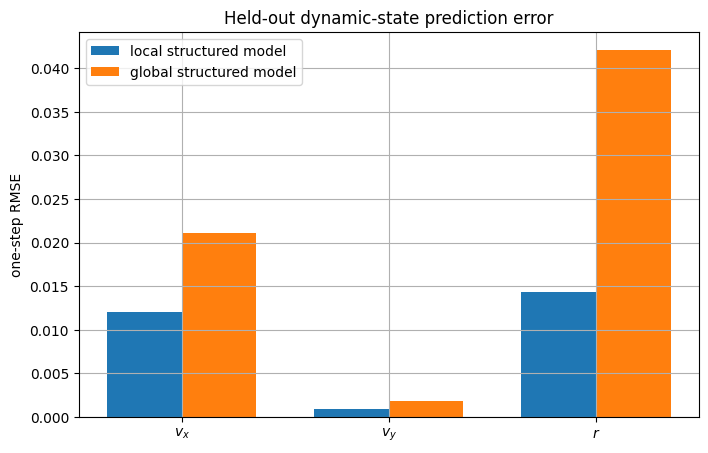

In [13]:
dynamic_idx = np.arange(3)

x_bar = np.arange(3)
width = 0.36

plt.figure()

plt.bar(
    x_bar - width/2,
    local_rmse[dynamic_idx],
    width=width,
    label="local structured model",
)

plt.bar(
    x_bar + width/2,
    global_rmse[dynamic_idx],
    width=width,
    label="global structured model",
)

plt.xticks(
    x_bar,
    [
        r"$v_x$",
        r"$v_y$",
        r"$r$",
    ],
)

plt.ylabel("one-step RMSE")
plt.title("Held-out dynamic-state prediction error")
plt.legend()
plt.show()


### How to read the RMSE figure

Lower bars are better.

Only the three **learned dynamic states** are shown because the other three rows use the same
analytical kinematic construction in both models.

The comparison therefore answers a clean question:

> does fitting the dynamic coefficients locally improve prediction relative to one global set of
> coefficients?

Here it does: the local model has a lower held-out one-step RMSE for all three learned states, and
the largest gain is in the yaw rate $r$, where the error drops by about a factor of three.

<a id="part-9"></a>
# Part IX — Why local models help

## IX.1 A nonlinear plant has operating-point-dependent derivatives

For a nonlinear transition

$$
x^+=f(x,u),
$$

the best first-order coefficients are

$$
A_q
=
\left.
\frac{\partial f}{\partial x}
\right|_{(x_q,u_q)},
$$

$$
B_q
=
\left.
\frac{\partial f}{\partial u}
\right|_{(x_q,u_q)}.
$$

Those derivatives change with the operating point.

A single global affine regression effectively averages incompatible local behaviors.

Local regression attempts to estimate the derivative-like behavior only where the MPC is currently
planning to operate.


<a id="part-10"></a>
# Part X — Model support versus prediction error

## X.1 Distance to the database

For every validation query, compute

$$
d_{\min}(z_q)
=
\min_i
\left\|
D(z_i-z_q)
\right\|_1.
$$

This is not a probabilistic uncertainty estimate.

It is a simple geometric indicator of how close the query is to stored experience.


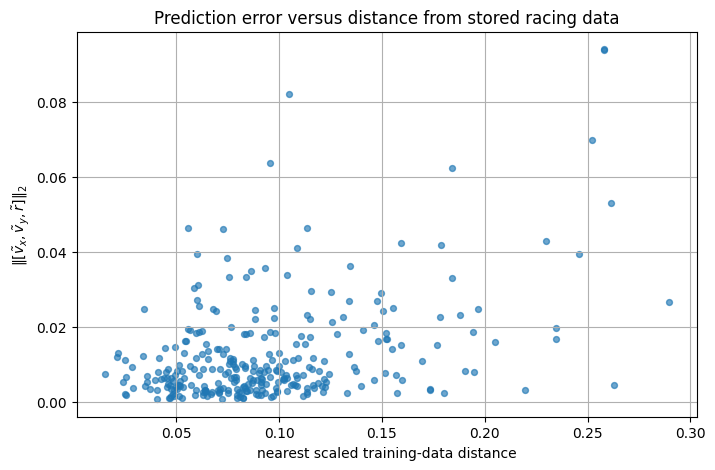

In [14]:
dynamic_error_norm = np.linalg.norm(
    local_error[:, :3],
    axis=1,
)

plt.figure()

plt.scatter(
    support_distance,
    dynamic_error_norm,
    s=18,
    alpha=0.65,
)

plt.xlabel("nearest scaled training-data distance")
plt.ylabel(
    r"$\|[\tilde v_x,\tilde v_y,\tilde r]\|_2$"
)
plt.title("Prediction error versus distance from stored racing data")
plt.show()


### How to read this figure

Points near the left are well supported by stored experience.

Points farther right are less well supported.

In this experiment, larger errors are somewhat more frequent at larger distances, but the scatter is
large. A perfectly monotone relationship should not be expected because:

- local nonlinearities differ;
- the selected neighbors excite the regressors more or less well;
- regression conditioning varies;
- distance is only a geometric proxy.

But a large support distance is a useful warning that the local model is being asked to predict
outside familiar data.

Note the horizontal scale: every validation query has a stored transition within a small fraction
of the bandwidth $h=5$, so the held-out lap tests interpolation inside familiar data rather than
extrapolation. Part XVII shows a query far outside the data.

<a id="part-11"></a>
# Part XI — Conditioning and regularization

## XI.1 Why the normal equations can become ill-conditioned

Local regression intentionally keeps only nearby points.

Those points can be nearly collinear in regressor space.

Then

$$
\Phi^\top W\Phi
$$

can have a large condition number.

This makes fitted coefficients sensitive to noise and floating-point perturbations.


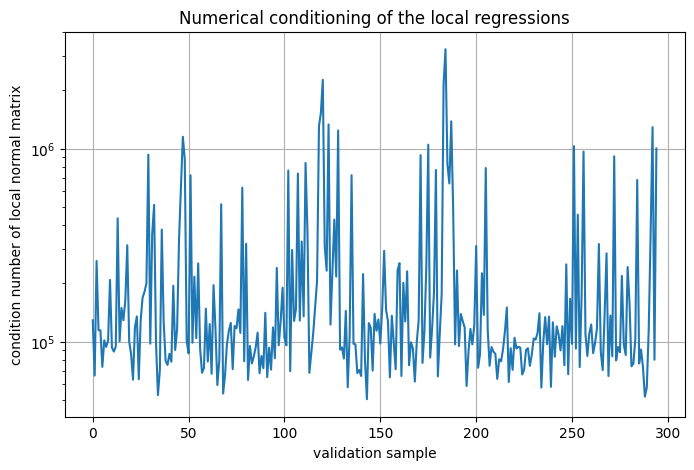

median condition number: 109890.47575768639
95th percentile: 925523.1365296915


In [15]:
plt.figure()

plt.semilogy(
    condition_numbers,
)

plt.xlabel("validation sample")
plt.ylabel(
    r"condition number of local normal matrix"
)
plt.title("Numerical conditioning of the local regressions")
plt.show()

print(
    "median condition number:",
    float(
        np.median(
            condition_numbers
        )
    ),
)

print(
    "95th percentile:",
    float(
        np.quantile(
            condition_numbers,
            0.95,
        )
    ),
)


## XI.2 Ridge regularization

Replacing

$$
\Phi^\top W\Phi
$$

by

$$
\boxed{
\Phi^\top W\Phi+\lambda I
}
$$

improves numerical conditioning.

But regularization also biases the coefficient estimate.

Therefore $\lambda$ is not “free accuracy.”

Setting

$$
\lambda=0,
$$

recovers unregularized weighted least squares. The value $\lambda=10^{-8}$ used here is only a
numerical safeguard against an exactly singular normal matrix, far too small to bias these fits
noticeably; the notebook makes the conditioning visible instead of hiding it behind a large
$\lambda$.


<a id="part-12"></a>
# Part XII — Feature design of the learned rows

## XII.1 Why does $v_x^+$ use acceleration but not steering?

The regression imposes

$$
v_x^+
=
f_{\mathrm{loc}}
(v_x,v_y,r,a_x).
$$

Yet the nonlinear simulator contains the term

$$
-\frac{F_{y,f}}{m}\sin\delta,
$$

so steering can influence longitudinal dynamics.

The restricted regression is therefore an **approximate structured model**, not an exact statement
of physical decoupling.

Advantages:

- fewer regression parameters;
- lower data requirement;
- easier numerical conditioning;
- direct use of obvious physical input channels.

Cost:

- neglected cross-coupling must be absorbed locally by the remaining state dependence and affine
offset.


## XII.2 Why do $v_y^+$ and $r^+$ use steering but not acceleration?

The same logic is used in the lateral dynamics:

$$
v_y^+,r^+
=
f_{\mathrm{loc}}
(v_x,v_y,r,\delta).
$$

Acceleration affects lateral behavior indirectly through changing $v_x$ over time, but it is not an
explicit regressor in those two one-step rows.

This is a **grey-box identification** choice: physics determines the model structure, data determine
the local coefficients.


<a id="part-13"></a>
# Part XIII — Building an affine LTV horizon

## XIII.1 From one local model to a sequence

An MPC horizon of length $N$ requires models

$$
(A_0,B_0,c_0),
\ldots,
(A_{N-1},B_{N-1},c_{N-1}).
$$

The horizon experiment below uses

$$
\boxed{
N=14,
}
$$

that is, $1.4$ s of prediction at $T_s=0.1$ s.

At each prediction step, local data are selected around the current predicted state/input pair.

Thus the model is **linear at each step but time-varying across the horizon**.


## XIII.2 Closed-loop versus prediction model

A subtle but important architecture is:

$$
\boxed{
\text{nonlinear simulator}
\overset{\text{data}}{\longrightarrow}
\text{local affine model}
\overset{\text{QP}}{\longrightarrow}
u
\overset{\text{apply}}{\longrightarrow}
\text{nonlinear simulator}.
}
$$

The affine model is never claimed to be the true vehicle.

It is a computational surrogate used inside the optimizer.


<a id="part-14"></a>
# Part XIV — Horizon-14 prediction experiment

## XIV.1 Use actual future inputs only to test the model

To isolate model accuracy, take a length-14 segment of the held-out validation lap.

We provide both predictive models with the **actual input sequence that was applied to the nonlinear
simulator**.

This is not a controller experiment.

It asks only:

> starting from the same initial state and using the same inputs, how accurately does the learned
> model predict the next 14 states?


In [16]:
H = 14
start = 145

U_horizon = U_val[
    start:start+H
]

X_true_horizon = X_val[
    start:start+H+1
]

X_local_horizon, local_diags = (
    rollout_affine_predictive_model(
        local_model,
        X_val[start],
        U_horizon,
    )
)

X_global_horizon, _ = (
    rollout_affine_predictive_model(
        global_model,
        X_val[start],
        U_horizon,
    )
)

local_horizon_error = (
    X_local_horizon
    - X_true_horizon
)

global_horizon_error = (
    X_global_horizon
    - X_true_horizon
)

print(
    "local horizon dynamic RMSE:",
    np.sqrt(
        np.mean(
            local_horizon_error[:, :3]**2
        )
    ),
)

print(
    "global horizon dynamic RMSE:",
    np.sqrt(
        np.mean(
            global_horizon_error[:, :3]**2
        )
    ),
)


local horizon dynamic RMSE: 0.020550129036448882
global horizon dynamic RMSE: 0.04075049509819846


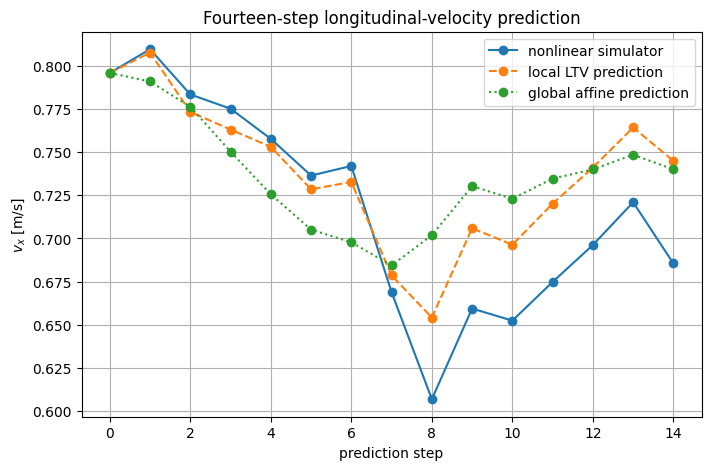

In [17]:
steps = np.arange(
    H + 1
)

plt.figure()

plt.plot(
    steps,
    X_true_horizon[:, 0],
    "-o",
    label="nonlinear simulator",
)

plt.plot(
    steps,
    X_local_horizon[:, 0],
    "--o",
    label="local LTV prediction",
)

plt.plot(
    steps,
    X_global_horizon[:, 0],
    ":o",
    label="global affine prediction",
)

plt.xlabel("prediction step")
plt.ylabel(r"$v_x$ [m/s]")
plt.title("Fourteen-step longitudinal-velocity prediction")
plt.legend()
plt.show()


### How to read the horizon figure

The nonlinear-simulator curve is the held-out ground truth.

Both prediction models start from exactly the same state at step zero.

After that, prediction errors feed back into their own future model queries.

This is harder than one-step prediction because errors propagate along the horizon.

In this segment the local LTV prediction follows the simulated $v_x$ closely over the first steps
and reproduces the sharp dip around step 8 in shape, though not in depth, so it stays above the
true speed afterwards; the global model smooths the dip out.

The error-norm plot below shows that the errors do not grow monotonically: they jump where the true
trajectory has a sharp transient (around step 8) and can shrink again when the predicted and true
trajectories come back together. Over the whole horizon the local model's dynamic-state RMSE is
about half that of the global model, although in the last few steps the two error norms are
comparable.


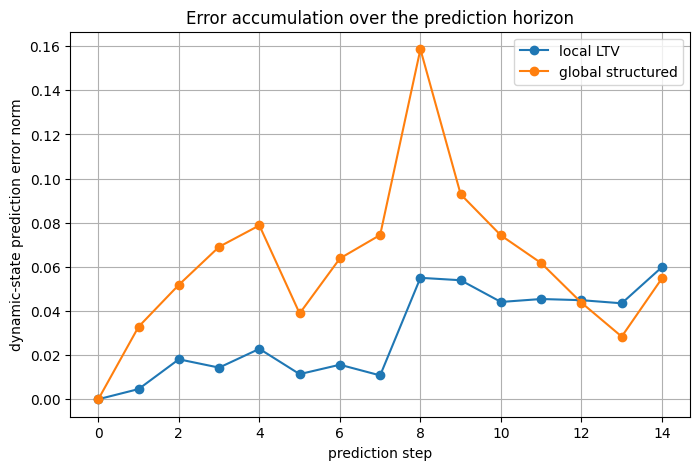

In [18]:
plt.figure()

plt.plot(
    steps,
    np.linalg.norm(
        local_horizon_error[:, :3],
        axis=1,
    ),
    "-o",
    label="local LTV",
)

plt.plot(
    steps,
    np.linalg.norm(
        global_horizon_error[:, :3],
        axis=1,
    ),
    "-o",
    label="global structured",
)

plt.xlabel("prediction step")
plt.ylabel("dynamic-state prediction error norm")
plt.title("Error accumulation over the prediction horizon")
plt.legend()
plt.show()


<a id="part-15"></a>
# Part XV — Why it is called LTV

## XV.1 The matrices change along the predicted trajectory

For each local horizon step, compute

$$
\|A_k-A_0\|_F
$$

and

$$
\|B_k-B_0\|_F.
$$

If these values are nonzero, the controller is not using one fixed linear model.


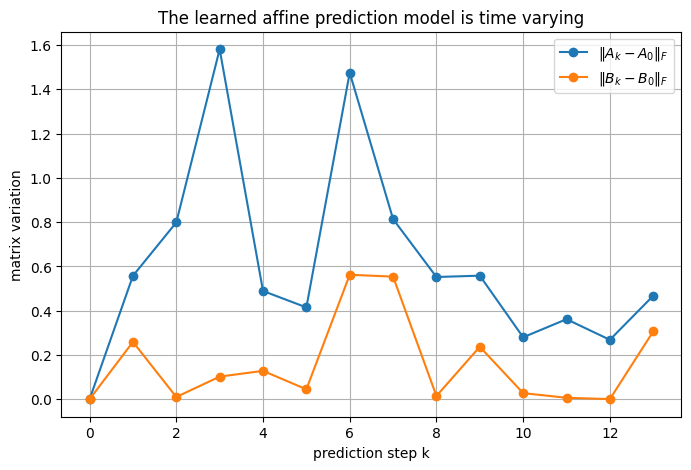

In [19]:
A_list = []
B_list = []

x_tmp = X_val[start].copy()

for u_tmp in U_horizon:
    A_tmp, B_tmp, c_tmp, diag_tmp = (
        local_model.fit(
            x_tmp,
            u_tmp,
        )
    )

    A_list.append(A_tmp)
    B_list.append(B_tmp)

    x_tmp = (
        A_tmp @ x_tmp
        + B_tmp @ u_tmp
        + c_tmp
    )

A_list = np.asarray(A_list)
B_list = np.asarray(B_list)

A_variation = np.array([
    np.linalg.norm(
        A_k - A_list[0],
        ord="fro",
    )
    for A_k in A_list
])

B_variation = np.array([
    np.linalg.norm(
        B_k - B_list[0],
        ord="fro",
    )
    for B_k in B_list
])

plt.figure()

plt.plot(
    np.arange(H),
    A_variation,
    "-o",
    label=r"$\|A_k-A_0\|_F$",
)

plt.plot(
    np.arange(H),
    B_variation,
    "-o",
    label=r"$\|B_k-B_0\|_F$",
)

plt.xlabel("prediction step k")
plt.ylabel("matrix variation")
plt.title("The learned affine prediction model is time varying")
plt.legend()
plt.show()


### Interpretation

The variation comes from two mechanisms:

1. the regression neighborhood changes as $(v_x,v_y,r,\delta,a_x)$ changes;
2. the analytic Frenet rows change with $e_\psi,e_y$ and track curvature $K(s)$.

So even if the optimization problem is linear/quadratic after the matrices are fixed, the matrices
themselves encode local nonlinear behavior.

The variation is not smooth. Each fit keeps the seven nearest transitions of every lap with almost
equal weights, so a small change of the query can swap neighbors and, with nearly collinear data,
change the coefficients abruptly. $B_k$ varies only through the regression, since the kinematic
rows of $B$ are zero.

<a id="part-16"></a>
# Part XVI — Local model support inside an MPC horizon

## XVI.1 One model-fit diagnostic is not enough

An MPC may begin in a well-supported region and predict into a poorly supported region several steps
ahead.

Therefore model-support diagnostics should be evaluated **along the complete prediction horizon**.


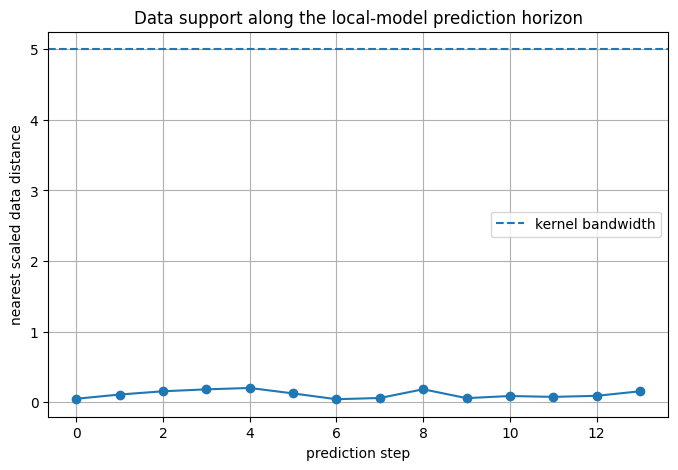

In [20]:
horizon_support = []
horizon_condition = []

x_tmp = X_val[start].copy()

for u_tmp in U_horizon:
    horizon_support.append(
        local_model.support_distance(
            x_tmp,
            u_tmp,
        )
    )

    A_tmp, B_tmp, c_tmp, diag_tmp = (
        local_model.fit(
            x_tmp,
            u_tmp,
        )
    )

    horizon_condition.append(
        np.max(
            diag_tmp.normal_condition_numbers
        )
    )

    x_tmp = (
        A_tmp @ x_tmp
        + B_tmp @ u_tmp
        + c_tmp
    )

plt.figure()

plt.plot(
    np.arange(H),
    horizon_support,
    "-o",
)

plt.axhline(
    5.0,
    linestyle="--",
    label="kernel bandwidth",
)

plt.xlabel("prediction step")
plt.ylabel("nearest scaled data distance")
plt.title("Data support along the local-model prediction horizon")
plt.legend()
plt.show()


In this experiment the whole predicted horizon stays far inside the bandwidth: every predicted
state-input pair has stored transitions close by.

A horizon point approaching or crossing the bandwidth would be an explicit warning:

$$
\boxed{
\text{the optimizer is planning where the identified local dynamics are poorly supported.}
}
$$

The local regression used here does not turn this distance into a formal uncertainty set.

Doing so would be an additional robust/learning-control extension.


<a id="part-17"></a>
# Part XVII — Out-of-distribution query

## XVII.1 Deliberately ask for an unfamiliar operating point

Consider a query with much larger speed, lateral velocity, yaw rate and acceleration than anything
in the stored training laps.

We do **not** present the resulting extrapolated model as trustworthy.

Instead, we inspect its support distance.


In [21]:
x_ood = np.array([
    4.0,   # vx
    1.0,   # vy
    4.0,   # yaw rate
    0.2,   # epsi
    5.0,   # s
    0.2,   # ey
])

u_ood = np.array([
    0.5,   # delta
    5.0,   # ax
])

ood_distance = local_model.support_distance(
    x_ood,
    u_ood,
)

A_ood, B_ood, c_ood, diag_ood = (
    local_model.fit(
        x_ood,
        u_ood,
    )
)

print(
    "nearest scaled data distance:",
    ood_distance,
)

print(
    "kernel bandwidth:",
    local_model.bandwidth,
)

print(
    "fallback used on laps:",
    diag_ood.support_fallback,
)


nearest scaled data distance: 8.546040889652584
kernel bandwidth: 5.0
fallback used on laps: [True, True, True, True]


## XVII.2 Interpretation

The nearest distance exceeds the bandwidth

$$
h=5,
$$

so the compact-support Epanechnikov kernel contains no training sample of any lap.

`LocalRacingModel` then falls back to the seven nearest transitions of each lap, widens the
bandwidth for that lap just enough to cover them, and flags the lap in `support_fallback`; here all
four laps are flagged. The numerical object remains inspectable, but the fallback is marked
explicitly.

The correct engineering conclusion is not

> “the model can still return a number, therefore it is valid.”

It is

$$
\boxed{
\text{the query is extrapolative and model reliability is unverified.}
}
$$


<a id="part-18"></a>
# Part XVIII — Bias–variance trade-off in bandwidth and neighborhood size

## XVIII.1 Small bandwidth

A small $h$ gives a very local fit.

Potential benefit:

- lower nonlinear-model bias.

Potential problems:

- too few points;
- large coefficient variance;
- ill-conditioning;
- no support.

---

## XVIII.2 Large bandwidth

A large $h$ includes more data.

Potential benefit:

- lower variance;
- better conditioning.

Potential problem:

- points from substantially different dynamics are averaged together;
- the model starts behaving like a global affine approximation.

The bandwidth is therefore a genuine identification hyperparameter, not merely a speed setting.

With the data of this notebook, $h=5$ exceeds the spread of the whole data set in the scaled
metric (Part IV), so locality is set by the neighborhood size of seven points per lap rather than
by $h$.


<a id="part-19"></a>
# Part XIX — Why local validation must be trajectory-based

## XIX.1 Random train/test splits can be misleading

Consecutive racing samples are strongly correlated:

$$
x_{k+1}
\approx x_k.
$$

If one randomly assigns individual time samples to training and validation, nearly identical
neighbors from the same lap can appear on both sides.

That can produce an overly optimistic validation error.

Using a **whole held-out lap** is a more meaningful first validation strategy for an iterative racing
task.


<a id="part-20"></a>
# Part XX — How this enters LMPC

## XX.1 Two distinct forms of learning

Racing LMPC can learn two different things.

### Terminal learning

Previous successful laps provide:

- a local safe set;
- a terminal cost / cost-to-go.

### Model learning

Previous transition data provide:

$$
(A_k,B_k,c_k).
$$

These mechanisms are complementary.

One learns **where it is useful/safe to terminate the finite horizon and what the continuation
costs**.

The other learns **how the vehicle is expected to move during the finite horizon**.


## XX.2 Structure of a racing LMPC

A racing LMPC built on this model combines:

- prediction horizon

$$
N=14;
$$

- a few stored trajectories for model learning (four here);
- a few stored trajectories for the local safe set;
- local safe-set point selection;
- local model regression;
- analytical Frenet linearization;
- a QP solved at every control step.

The controller's optimized input is then applied to the nonlinear dynamic bicycle simulator.

That closes the learning loop:

$$
\boxed{
\text{experience}
\rightarrow
\text{prediction model + terminal data}
\rightarrow
\text{new control}
\rightarrow
\text{new experience}.
}
$$


<a id="part-21"></a>
# Part XXI — The racing LMPC cost: an important detail

## XXI.1 No conventional state-tracking cost for racing

A racing LMPC does not need a conventional state-tracking cost, because its performance objective is
lap time; the nominal state and input costs can be set to zero:

$$
Q_{\mathrm{LMPC}}=0,
$$

$$
R_{\mathrm{LMPC}}=0.
$$

Smoothness then comes from an input-rate penalty, for example

$$
\boxed{
\Delta u^\top
\operatorname{diag}
\left(
5,\;50
\right)
\Delta u
}
$$

written in code as

$$
dR=5[1,10].
$$

The learned terminal cost counts remaining samples to the lap finish.

Therefore the principal performance objective is lap completion/time, with smoothing and slack
penalties supporting numerical/control behavior.


## XXI.2 Local safe-set sizing

The local safe set is sized by the number of stored laps it draws from and the number of points it
selects, for example

$$
\texttt{numSS\_it}=4,
$$

and

$$
\texttt{numSS\_Points}
=
12\times4
=
48.
$$

The controller selects local safe-set samples from the best/fastest stored laps around a predicted
terminal point.

This is different from taking the convex hull of **all states from all laps**.

Locality reduces the optimization dimension and avoids combining unrelated parts of a closed racing
track.


<a id="part-22"></a>
# Part XXII — A subtle geometry issue: convex hulls in Frenet coordinates

## XXII.1 Is a convex local safe set automatically inside the lane?

The lane constraint is

$$
|e_y|\le W.
$$

If two stored points use the **same local Frenet chart** and both satisfy the interval constraint,
then convex combinations preserve the scalar $e_y$ bound because an interval is convex.

However, a closed track creates an additional issue:

$$
s=0
$$

and

$$
s=L
$$

represent neighboring physical positions but numerically distant curvilinear coordinates.

A careless convex combination across the finish-line discontinuity can therefore be geometrically
misleading.

A practical remedy is to shift the progress coordinate of stored states by the track length $L$
around the finish line when constructing terminal data, so that physically neighboring points also
have neighboring $s$ values.


<a id="part-23"></a>
# Part XXIII — Why a learned LTV model can work on a highly nonlinear vehicle

## XXIII.1 The key is not that the plant became linear

The nonlinear bicycle dynamics remain nonlinear.

The approach relies on:

1. **short prediction horizons**;
2. **receding-horizon feedback**;
3. **local regression around operating points already visited**;
4. **recomputation of the model as the operating point changes**;
5. **analytical kinematics where reliable physics is available**;
6. successful iterative data keeping the controller near progressively relevant regions.

Thus the useful approximation is local:

$$
f(x,u)
\approx
A_qx+B_qu+c_q
$$

for

$$
(x,u)\approx(x_q,u_q),
$$

not globally over the entire state space.


## XXIII.2 Why this does not automatically imply robustness

A good nominal local prediction model does not by itself guarantee:

- recursive feasibility under model mismatch;
- probabilistic safety;
- bounded closed-loop error;
- protection against sudden friction changes;
- safety under perception/localization errors.

Those require additional robust/stochastic/adaptive constructions.

Learning MPC racing is an effective learning-control architecture; it should not be relabelled as
a formal robust-MPC certificate.


<a id="part-24"></a>
# Part XXIV — Common pitfalls

## XXIV.1 Pitfall: local linear model means the real system is linear

No.

The plant remains nonlinear. Only the optimizer's short-horizon surrogate is locally affine.

---

## XXIV.2 Pitfall: nearest neighbors are selected using $(s,e_y)$

Not in the metric of this predictive model.

It searches in

$$
[v_x,v_y,r,\delta,a_x].
$$

Track geometry enters separately through the analytic Frenet equations.

---

## XXIV.3 Pitfall: the regression learns all six state equations

No.

Only $v_x,v_y,r$ are locally regressed.

The Frenet kinematics are analytically linearized.

---

## XXIV.4 Pitfall: $c_k$ can be omitted because the model is “linearized”

No.

A local approximation around a nonzero operating point is generally affine.

---

## XXIV.5 Pitfall: low training residual proves predictive accuracy

No.

Validation should use unseen trajectories/operating points and multi-step rollout tests.

---

## XXIV.6 Pitfall: large bandwidth is always safer because it uses more data

No.

It can reduce variance but increase nonlinear-model bias.

---

## XXIV.7 Pitfall: ridge regularization is free accuracy

No.

It improves conditioning but biases the coefficients. The tiny $\lambda=10^{-8}$ used here is only a
safeguard against an exactly singular normal matrix; a larger $\lambda$ must be validated on
held-out data, like the bandwidth.

---

## XXIV.8 Pitfall: an extrapolated model is trustworthy because the solver returns coefficients

No.

A model outside the data-support region is numerically defined but empirically unvalidated.


<a id="part-25"></a>
# Part XXV — Check your understanding

Try to answer each question before opening its answer.

**1. What is the main difference between the nonlinear simulator and the LMPC predictive model?**

<details>
<summary>Answer</summary>

The simulator propagates nonlinear dynamic-bicycle/Frenet dynamics. The controller uses a locally
identified affine time-varying surrogate
$x^+=A_kx+B_ku+c_k$.

</details>

**2. Which states are learned from data?**

<details>
<summary>Answer</summary>

The next-step longitudinal velocity, lateral velocity, and yaw rate:
$v_x^+,v_y^+,r^+$.

</details>

**3. Which states use analytical kinematics?**

<details>
<summary>Answer</summary>

Heading error $e_\psi$, curvilinear progress $s$, and lateral deviation $e_y$.

</details>

**4. What query vector is used to select local data?**

<details>
<summary>Answer</summary>

$$
z=[v_x,v_y,r,\delta,a_x]^\top.
$$

</details>

**5. Why is $v_x$ scaled by 0.1 in the distance metric?**

<details>
<summary>Answer</summary>

To prevent its numerical range/units from dominating the local-neighbor distance relative to the
other features.

</details>

**6. What kernel is used?**

<details>
<summary>Answer</summary>

The Epanechnikov kernel, a compact-support quadratic kernel
$w=(3/4)[1-(d/h)^2]$ for selected points inside bandwidth $h=5$.

</details>

**7. Why fit an affine rather than homogeneous linear model?**

<details>
<summary>Answer</summary>

The local expansion point is generally nonzero, so the intercept
$c=f(x_q,u_q)-A_qx_q-B_qu_q$ is required.

</details>

**8. Why does the model use only acceleration in the $v_x$ input row?**

<details>
<summary>Answer</summary>

It is a structured grey-box modeling choice that reduces parameters and encodes the principal
longitudinal actuation channel, even though the full nonlinear model contains additional coupling.

</details>

**9. What makes the model LTV?**

<details>
<summary>Answer</summary>

The local data neighborhood and the analytical Frenet Jacobian change along the predicted
trajectory, so $(A_k,B_k,c_k)$ vary with prediction step $k$.

</details>

**10. Why validate on a held-out lap instead of random samples?**

<details>
<summary>Answer</summary>

Time-adjacent racing data are strongly correlated. A random split can leak almost identical
neighbors into both train and test sets.

</details>

**11. What does the nearest-data distance tell us?**

<details>
<summary>Answer</summary>

It is a geometric support diagnostic: large distance indicates extrapolation. It is not a calibrated
probabilistic uncertainty measure.

</details>

**12. Why can ridge regularization help?**

<details>
<summary>Answer</summary>

Local samples can make $\Phi^\top W\Phi$ nearly singular. Adding $\lambda I$ improves conditioning
but introduces bias.

</details>

**13. How can a local LTV model control a nonlinear vehicle?**

<details>
<summary>Answer</summary>

The approximation only needs to be useful locally over a short horizon. Receding-horizon feedback
and repeated model updates prevent the controller from relying on one global approximation.

</details>

**14. What are the two separate learning mechanisms in racing LMPC?**

<details>
<summary>Answer</summary>

Model learning provides the finite-horizon dynamics. Safe-set/value learning provides terminal
geometry and terminal cost from successful laps.

</details>

**15. Does good local prediction prove closed-loop safety?**

<details>
<summary>Answer</summary>

No. Prediction validation is necessary but not a robust/stochastic safety guarantee.

</details>


<a id="part-26"></a>
# Part XXVI — Exercises

### Exercise 1 — weighted normal equations

Starting from

$$
\sum_i w_i(y_i-\phi_i^\top\theta)^2+\lambda\|\theta\|_2^2,
$$

derive the normal equations.

---

### Exercise 2 — scaling

Remove the $0.1$ scale factor on $v_x$.

Compare the selected neighbors for several queries and explain which feature dominates.

---

### Exercise 3 — bandwidth sweep

Repeat validation for

$$
h\in\{1,2,5,10\}.
$$

Report:

- one-step RMSE;
- support failures;
- condition-number statistics.

Explain the bias–variance trade-off.

---

### Exercise 4 — maximum points per lap

Repeat with

$$
N_{\mathrm{local}}
\in
\{3,7,15\}.
$$

Does more data always improve the local model?

---

### Exercise 5 — ridge regularization

Evaluate several values of $\lambda$.

Plot coefficient conditioning and held-out prediction error.

---

### Exercise 6 — remove the affine offset

Force

$$
c=0.
$$

Compare held-out errors with the affine model.

Explain the result using local linearization around a nonzero operating point.

---

### Exercise 7 — add steering to the $v_x$ regression

Fit

$$
v_x^+
$$

using both $\delta$ and $a_x$.

Does the extra regressor improve validation sufficiently to justify the additional parameter?

---

### Exercise 8 — add acceleration to the lateral rows

Repeat the previous experiment for $v_y^+$ and $r^+$.

Discuss physical coupling versus data efficiency.

---

### Exercise 9 — global versus local

Compare the global and local structured models over:

- low curvature;
- high curvature;
- low speed;
- high speed.

Where is locality most useful?

---

### Exercise 10 — multi-step horizon

Repeat the horizon experiment for

$$
N=5,\;14,\;30.
$$

Explain why one-step accuracy does not directly predict long-horizon accuracy.

---

### Exercise 11 — data-support monitor

Design a rule that flags an MPC prediction if any horizon point satisfies

$$
d_{\min}>d_{\mathrm{warn}}.
$$

What should the controller do after a warning?

---

### Exercise 12 — curvature derivative

The local kinematic linearization of Part VII treats curvature as constant around the query.

Derive the additional terms that would appear if

$$
\frac{dK}{ds}
$$

were included.

---

### Exercise 13 — uncertainty model

Use held-out residuals to estimate a local covariance matrix for model error.

How could such a covariance be used in stochastic or robust MPC?

---

### Exercise 14 — error-dynamics learning

Instead of learning the full local dynamic rows, suppose a nominal physics model
$f_{\mathrm{nom}}(x,u)$ is available.

Define residual data

$$
e_i
=
x_{i+1}
-
f_{\mathrm{nom}}(x_i,u_i).
$$

Formulate a local regression model for the residual rather than the complete dynamics.

Discuss why this can reduce the learning burden.


<a id="part-27"></a>
# Part XXVII — References

The prediction model follows the local-regression approach of Rosolia and Borrelli (2020). The
implementation in `racing.py` uses:

- state $[v_x,v_y,r,e_\psi,s,e_y]$;
- input $[\delta,a_x]$;
- outer sampling time $T_s=0.1$ s;
- the nonlinear dynamic bicycle model of a 1:10-scale RC car (BARC parameters);
- local query features $[v_x,v_y,r,\delta,a_x]$;
- feature scaling $\operatorname{diag}(0.1,1,1,1,1)$;
- the Epanechnikov kernel with bandwidth $h=5$;
- maximum seven regression samples per stored lap;
- learned rows for $v_x,v_y,r$;
- analytic Frenet rows for $e_\psi,s,e_y$;
- prediction horizon $N=14$;
- four stored training laps.

The resulting prediction model has the affine form

$$
\boxed{
x_{k+1}=A_kx_k+B_ku_k+c_k.
}
$$

Further references:

- U. Rosolia and F. Borrelli, “Learning How to Autonomously Race a Car: A Predictive Control
  Approach,” *IEEE Transactions on Control Systems Technology*, 28(6), 2713–2719, 2020,
  DOI 10.1109/TCST.2019.2948135.
- U. Rosolia, A. Carvalho, and F. Borrelli, “Autonomous Racing using Learning Model Predictive
  Control,” *American Control Conference*, 2017, DOI 10.23919/ACC.2017.7963748.
- L. Ljung, *System Identification: Theory for the User*, 2nd ed., Prentice Hall, 1999.
- T. Hastie, R. Tibshirani, J. Friedman, *The Elements of Statistical Learning*, 2nd ed.,
  Springer, 2009 (Chapter 6 covers kernel smoothing and the Epanechnikov kernel).
- R. Rajamani, *Vehicle Dynamics and Control*, 2nd ed., Springer, 2012.
- H. B. Pacejka, *Tire and Vehicle Dynamics*, 3rd ed., Butterworth-Heinemann, 2012.

A useful modern extension is to learn **error dynamics** around a nominal physics-based model
instead of learning the whole local model; that idea is left as Exercise 14.